# Inner-Boundary Magnetic Field Map (ZDI-Style Starter)

This example loads the 3D BATSRUS sample, samples the **inner boundary shell** (`R=1`) using the library, and makes lat/lon magnetic maps.

The notebook uses library helpers for **sampling** and **spherical component transforms**, then plots directly with Matplotlib (`pcolormesh`, `contour`, `quiver`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

from starwinds_analysis.smart_ds import SmartDs
from starwinds_analysis.data.samples import get_sample
from starwinds_analysis.analysis.shells import integrate_shell_scalar

plt.rcParams['figure.dpi'] = 120


## Load the 3D Sample and Configure the Radius Scale

We feed the stellar radius into the BATSRUS/griblet graph near the top so SI conversions are available consistently.

In [2]:
# DONE get_sample should return path object.
DATA_FILE = get_sample('3d__var_1_n00060000.plt')
STAR_RADIUS_M = 696_000_000.0

# Instead, get_sample can print what file it is getting. It is really only used interactively anyhow.
print('Using:', DATA_FILE)
# DONE why do have star_radius and body-radius? use STAR_RADIUS_M directly.
sds = SmartDs.from_file(DATA_FILE)
sds.add_batsrus_graph(body_radius_m=STAR_RADIUS_M)

print(sds)


Using: /Users/dagfev/Documents/starwinds/starwinds-analysis/sample_data/3d__var_1_n00060000.plt
SmartDs
  Title: BATSRUS: 3D Data, 2011/02/16 17:26:00.000
  Zone : 3D   N=0060000
  Points: 794624
  Variables: 24


## Sample the Inner Boundary Shell (`R = 1`) and Compute Components

This builds a regular spherical `(theta, phi)` mesh in the notebook, resamples **corner points** with the generic `sds.resample(...)`, and computes:

- `B_r` (radial)
- `B_phi` (azimuthal / eastward)
- `B_meridional = -B_theta` (northward tangent)
- `|B_tan|`

Internal field values are SI (`T`); plotting below uses `G`.


In [ ]:
R_BOUNDARY = 1.0
N_POLAR = 64
N_AZIMUTH = 2 * N_POLAR
B_PLOT_UNIT = 'G'
B_SCALE = 1e4 if B_PLOT_UNIT == 'G' else 1.0

# DONE this comment is useless; just say we are using corners, thats it.
# Using corners only: build a shell corner mesh and resample once onto those points.
# DONE we dont heed to label the variables with _corner please remove.
theta_edges = np.linspace(0.0, np.pi, N_POLAR + 1)
phi_edges = np.linspace(-np.pi, np.pi, N_AZIMUTH + 1)
theta_grid, phi_grid = np.meshgrid(theta_edges, phi_edges, indexing='ij')

sin_theta = np.sin(theta_grid)
x_shell = R_BOUNDARY * sin_theta * np.cos(phi_grid)
y_shell = R_BOUNDARY * sin_theta * np.sin(phi_grid)
z_shell = R_BOUNDARY * np.cos(theta_grid)

sample_xyz = np.stack((x_shell, y_shell, z_shell), axis=-1)[None, ...]
shell_ds = sds.resample(
    sample_xyz,
    coordinate_fields=('X [R]', 'Y [R]', 'Z [R]'),
    fields=('B_x [T]', 'B_y [T]', 'B_z [T]'),
    method='nearest',
)

b_r_T = np.asarray(shell_ds('B_r [T]'))[0]
b_theta_T = np.asarray(shell_ds('B_theta [T]'))[0]
b_phi_T = np.asarray(shell_ds('B_phi [T]'))[0]
b_meridional_T = -b_theta_T  # northward on a latitude map
b_tan_T = np.sqrt(b_phi_T**2 + b_meridional_T**2)

r_shell = np.asarray(shell_ds('R [R]'))[0]
theta_shell = np.asarray(shell_ds('theta [rad]'))[0]
phi_shell = np.asarray(shell_ds('phi [rad]'))[0]
# Use the explicit edge-angle mesh for pcolormesh corner coordinates.
# (Longitude on the poles is singular/undefined, so recipe-derived longitude can contain non-finite values there.)
lat_deg = 90.0 - np.degrees(theta_grid)
lon_deg = np.degrees(phi_grid)

b_r = B_SCALE * b_r_T
b_phi = B_SCALE * b_phi_T
b_meridional = B_SCALE * b_meridional_T
b_tan = B_SCALE * b_tan_T

print('Shell grid shape (theta, phi):', theta_shell.shape)
print('Radius:', float(np.nanmean(r_shell)))
print('Plot unit:', B_PLOT_UNIT)


Shell corner grid shape (theta, phi): (65, 129)
Radius: 1.0
Plot unit: G


## ZDI-Style Component Maps (Radial / Azimuthal / Meridional)

Conventions used here:

- **Radial**: outward normal component (`B_r`)
- **Azimuthal**: `+phi` direction (eastward on the lat/lon map)
- **Meridional**: northward tangent component (`-B_theta`) so it follows latitude intuition

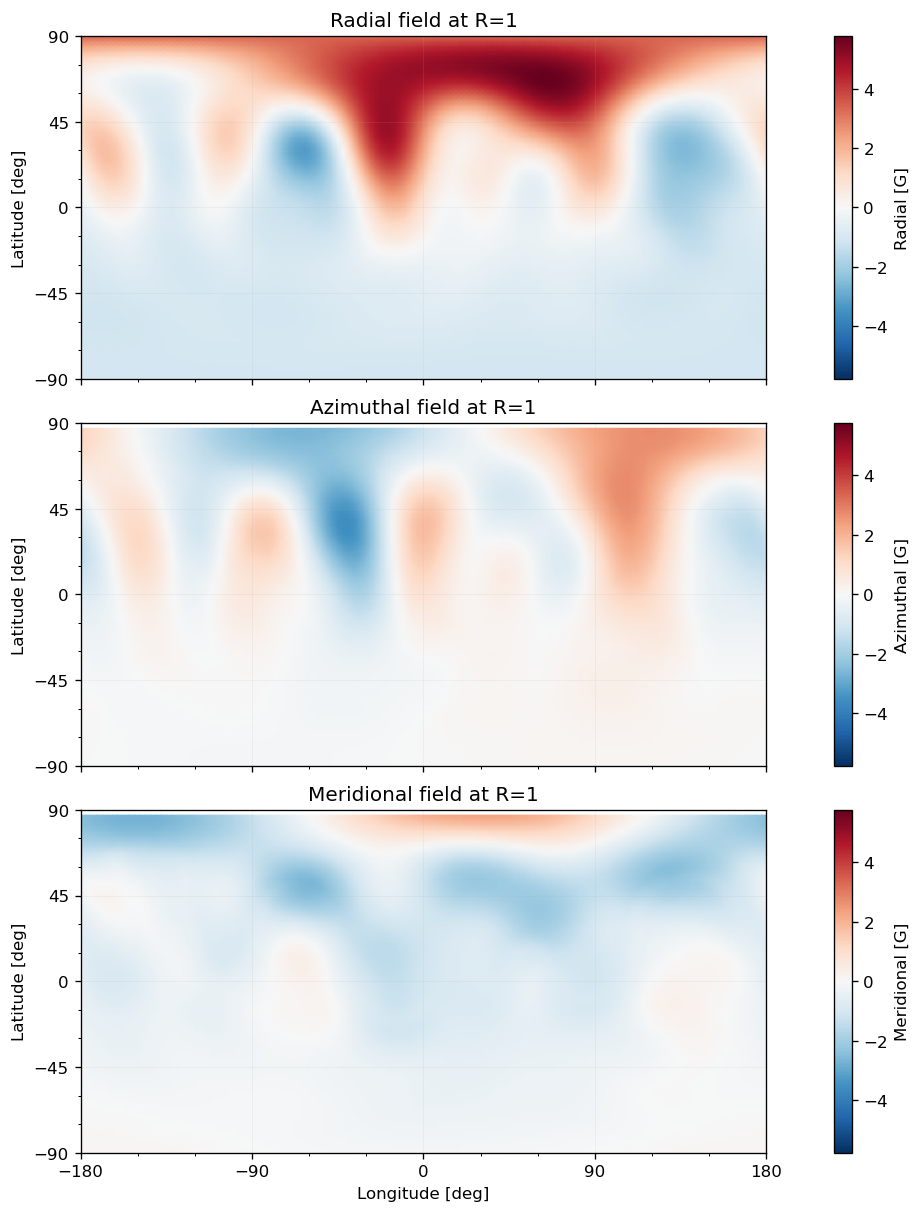

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)
components = [
    ('Radial', b_r),
    ('Azimuthal', b_phi),
    ('Meridional', b_meridional),
]
# DONE simplify the following line.
vabs = np.nanmax(np.abs(np.stack([b_r, b_phi, b_meridional])))

for ax, (label, arr) in zip(np.ravel(axs), components):
    # Corner-valued pcolormesh (no centre grid in this first pass).
    img = ax.pcolormesh(
        lon_deg,
        lat_deg,
        arr,
        shading='gouraud',
        cmap='RdBu_r',
        vmin=-vabs,
        vmax=vabs,
    )
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.xaxis.set_major_locator(MultipleLocator(90))
    ax.xaxis.set_minor_locator(MultipleLocator(30))
    ax.yaxis.set_major_locator(MultipleLocator(45))
    ax.yaxis.set_minor_locator(MultipleLocator(15))
    ax.grid(which='major', alpha=0.15, linewidth=0.5)
    ax.set_ylabel('Latitude [deg]')
    ax.set_title(f'{label} field at R={R_BOUNDARY:g}')
    ax.set_aspect('equal')
    fig.colorbar(img, ax=ax, label=f'{label} [{B_PLOT_UNIT}]')

axs[-1].set_xlabel('Longitude [deg]')
plt.show()


## Tangential Field as Vectors on a Lat/Lon Map

This plot shows the tangential field in two ways:

- **Background color**: tangential magnetic strength `|B_tan|`
- **Arrows**: tangential field direction in the local surface tangent plane

Arrow meaning (important):

- Arrow **direction** follows the tangential field direction (`B_phi`, meridional)
- Arrow **length is normalized** (fixed plotting length), so it does **not** encode field magnitude
- Tangential field magnitude is encoded by the background colors
- The east-west arrow component is corrected by `cos(latitude)` so the direction is sensible on a lon/lat map


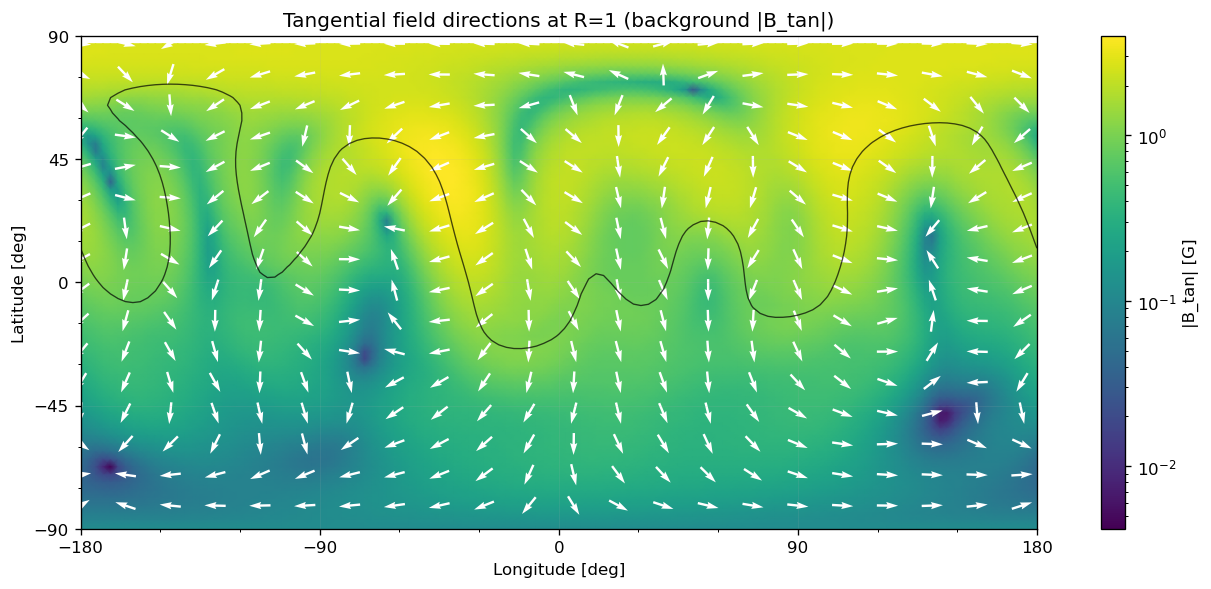

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
img = ax.pcolormesh(
    lon_deg,
    lat_deg,
    b_tan,
    shading='gouraud',
    cmap='viridis',
    norm='log',
)
img.cmap.set_under(img.cmap(0.0))

I_STEP, J_STEP = 4, 6
lon_q = lon_deg[::I_STEP, ::J_STEP]
lat_q = lat_deg[::I_STEP, ::J_STEP]
b_phi_q = b_phi[::I_STEP, ::J_STEP]
b_mer_q = b_meridional[::I_STEP, ::J_STEP]

# DONE investigate skipping INSIDE quiver i am pretty sure the functionality is present there.
# Quiver skips masked vectors, so we sample a regular subset and mask poles/invalid arrows.
# DONE is this required? Check if quiver can do this internally.
# Yes: on a lat/lon plot, east-west angular distance shrinks by cos(latitude), so we rescale here.
cos_lat = np.cos(np.deg2rad(lat_q))
u = b_phi_q / cos_lat
v = b_mer_q
arrow_len_deg = 8.0
mag = np.hypot(u, v)
u = np.ma.masked_invalid(arrow_len_deg * u / mag)
v = np.ma.masked_invalid(arrow_len_deg * v / mag)

ax.quiver(
    lon_q,
    lat_q,
    u,
    v,
    color='white',
    angles='xy',
    scale_units='xy',
    scale=1.0,
    width=0.0025,
    pivot='mid',
)

# Polarity inversion line: B_r = 0 (drawn on the same corner grid values).
ax.contour(lon_deg, lat_deg, b_r, levels=[0.0], colors='black', linewidths=0.8, alpha=0.7)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.xaxis.set_major_locator(MultipleLocator(90))
ax.xaxis.set_minor_locator(MultipleLocator(30))
ax.yaxis.set_major_locator(MultipleLocator(45))
ax.yaxis.set_minor_locator(MultipleLocator(15))
ax.grid(which='major', alpha=0.15, linewidth=0.5)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
ax.set_title(f'Tangential field directions at R={R_BOUNDARY:g} (background |B_tan|)')
fig.colorbar(img, ax=ax, label=f'|B_tan| [{B_PLOT_UNIT}]')
plt.show()


## Quick Boundary Summary (Useful Extra)

A few easy quantities to compute from the same shell sample:

- RMS strengths of radial / azimuthal / meridional / tangential components
- (cell-area flux integrals are left commented out in this corners-only first pass)


In [6]:
# Corner-sampled values are great for maps, but a cell-area radial-flux integral wants
# cell values paired with cell areas. That is left commented out in this corners-only pass.
#
# dphi = np.diff(phi_edges)
# area_unit = (np.cos(theta_edges[:-1]) - np.cos(theta_edges[1:]))[:, None] * dphi[None, :]
# area_shell_m2 = ((R_BOUNDARY * STAR_RADIUS_M) ** 2) * area_unit[None, ...]
# b_r_cell_T = 0.25 * (
#     b_r_T[:-1, :-1] + b_r_T[1:, :-1] + b_r_T[:-1, 1:] + b_r_T[1:, 1:]
# )
# signed_flux_Wb, signed_cov = integrate_shell_scalar(b_r_cell_T[None, ...], area_shell_m2[:1])
# unsigned_flux_Wb, unsigned_cov = integrate_shell_scalar(np.abs(b_r_cell_T)[None, ...], area_shell_m2[:1])

summary = {
    f'RMS B_r [{B_PLOT_UNIT}]': float(np.sqrt(np.nanmean(b_r**2))),
    f'RMS B_azimuthal [{B_PLOT_UNIT}]': float(np.sqrt(np.nanmean(b_phi**2))),
    f'RMS B_meridional [{B_PLOT_UNIT}]': float(np.sqrt(np.nanmean(b_meridional**2))),
    f'RMS |B_tan| [{B_PLOT_UNIT}]': float(np.sqrt(np.nanmean(b_tan**2))),
}
summary


{'RMS B_r [G]': 1.9016425963025485,
 'RMS B_azimuthal [G]': 0.974045811660223,
 'RMS B_meridional [G]': 0.9094075352776959,
 'RMS |B_tan| [G]': 1.3325866982799566}

## Easy Follow-Ups

- compare two timesteps side-by-side using the same plotting helpers
- switch `background="radial"` in the vector plot to show tangential arrows over radial polarity
- repeat at `R > 1` to see how the magnetic topology opens with height